<H1>Summarize and visualize variables<H1>

<H2> Import packages </H2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

<H2>Read and check the dataset</H2>

In [2]:
data = pd.read_csv('/Path/to/analysis_variables_grouped_by_id_and_set_size.csv')

In [3]:
data.head()

,study,experiment,id,set_size,trial_count,rt_mean,rt_sd,rt_min,rt_q1,rt_median,...,hit_rate,false_alarm_rate,correct_rejection_rate,miss_rate,dprime,aprime,response_bias,response_bias_probability,k,k_modified
0,1,1,1,4,180.0,970.128541,353.799226,470.861221,778.167652,888.069282,...,0.807692,0.335165,0.664835,0.192308,1.295119,0.823944,0.571823,0.221864,1.890110,1.890110
1,1,1,1,6,180.0,1103.674229,544.873696,557.199152,827.679892,994.650463,...,0.719780,0.423077,0.576923,0.280220,0.776217,0.731625,0.571823,0.194080,1.780220,1.780220
2,1,1,1,8,180.0,1153.791969,523.389215,533.889540,837.827655,1022.851470,...,0.620879,0.543956,0.456044,0.379121,0.197385,0.573142,0.582873,0.209098,0.615385,0.649168
3,1,1,2,4,180.0,780.464632,446.208231,315.912005,599.068296,671.545011,...,0.939560,0.368132,0.631868,0.060440,1.887899,0.878134,0.654696,0.607144,2.285714,2.285714
4,1,1,2,6,180.0,802.904013,367.442195,386.033923,582.603485,704.312030,...,0.884615,0.620879,0.379121,0.115385,0.890589,0.748447,0.754144,0.753085,1.582418,1.582418


In [4]:
#Uncomment there is an extra column at the beginning
#data = data.drop(data.columns[[0]], axis = 1)
#data.head()

<H2>Set function parameters</H2>

In [5]:
grouping_variables = ['study', 'experiment', 'set_size']
variables_to_explore = ['rt_mean', 'rt_sd', 'rt_min', 'rt_q1', 'rt_median', 'rt_q3', 'rt_max',
                                                            'accuracy', 'hit_rate', 'false_alarm_rate', 'correct_rejection_rate', 
                                                            'dprime', 'aprime', 'response_bias', 'response_bias_probability', 'k', 'k_modified']
omit_outliers = True #If True, input the threshold below
outlier_threshold = 1.5 #specify in distance from the IQR

<H2>Remove outliers</H2> (if specified)

In [6]:
def remove_iqr_outliers(data, value_cols=None, group_cols=None, outlier_threshold = 1.5):
    
    from pandas.core.groupby.generic import DataFrameGroupBy
    """
    Remove outliers using the threshold*IQR rule.

    Parameters:
    - data : pd.DataFrame or DataFrameGroupBy
        Input dataframe or grouped dataframe.
     - value_cols : list-like, optional
        Columns to evaluate. If None, all numeric columns are used.
    - group_cols : list-like, optional
        Columns to group the data frame. If None, outliers will be removed based on the whole column.

    Returns:
    - pd.DataFrame
        DataFrame with outlier rows removed within each level of the specified grouping variables.
    """
    global data_without_outliers
    
    if omit_outliers == True : 
        def _filter_group(df):
            cols = value_cols
            if cols is None:
                cols = df.select_dtypes(include="number").columns

            mask = pd.Series(True, index=df.index)

            for col in cols:
                q1 = df[col].quantile(0.25)
                q3 = df[col].quantile(0.75)
                iqr = q3 - q1

                lower = q1 - outlier_threshold * iqr
                upper = q3 + outlier_threshold * iqr

                df[col] = df[col].mask(~(df[col].between(lower, upper) | df[col].isna()), np.nan)



            return df

        if group_cols is not None:
            data_without_outliers = data.groupby(group_cols).apply(_filter_group).reset_index(drop=True)
            return (data_without_outliers)
        else:
            data_without_outliers = _filter_group(data)
            return (data_without_outliers)

    else :
        return (df)

In [7]:
if omit_outliers == True :
    data = remove_iqr_outliers(data, value_cols=variables_to_explore, group_cols=['study', 'experiment', 'set_size'], outlier_threshold=outlier_threshold)
else :
    print("no outliers were removed.")

/var/folders/qb/t_w1lk2x7wv7zpjtqxx1t4q80000gn/T/ipykernel_60607/2272672626.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_without_outliers = data.groupby(group_cols).apply(_filter_group).reset_index(drop=True)


In [8]:
data.shape

(8318, 27)

In [9]:
data[variables_to_explore].isnull().sum() #make sure that outliers were replaced with NaN if specified

rt_mean                       186
rt_sd                         350
rt_min                        296
rt_q1                         119
rt_median                     157
rt_q3                         231
rt_max                        343
accuracy                      904
hit_rate                     1048
false_alarm_rate              241
correct_rejection_rate        288
dprime                        871
aprime                       1041
response_bias                 327
response_bias_probability     239
k                             906
k_modified                    479
dtype: int64

<H2>Generate a summary table<H2>

In [10]:
def summary_table(df, value_cols=None, group_cols=None):

    """
    Parameters:
    - data : pd.DataFrame
    - value_cols : list-like, optional
        Columns to evaluate. If None, all numeric columns are used.
    - group_cols : list-like, optional
        Columns to group the data frame. If None, summaries will be based on the whole column.

    Returns:
    - pd.DataFrame
        DataFrame with outliers replaced with NaN within each level of the specified grouping variables.
    """

    global summary
    
    def group_if_needed(df, do_group):
    
        """
        Groups a DataFrame by 'group_col' if this value is not None.
        Otherwise, returns the DataFrame unchanged.
        """
        
        if do_group is not None:
            return df.groupby(group_cols)
        else:
            return df
    
    df = group_if_needed(df, do_group=group_cols)

    if value_cols is not None :
        df = df[value_cols]
    else : print("all columns were used.")

    summary = df.describe(percentiles=[0.25, 0.5, 0.75]).reset_index()

    return summary

In [11]:
# Example Usage:

# 1. Grouped by multiple columns:
# summary_table(df=data, value_cols=variables_to_explore, group_cols=['study', 'experiment', 'set_size'])
#
# 2. Entire dataset (no grouping):
# summary_table(df=data, value_cols=variables_to_explore, group_cols=None)  
#
# 3. Entire dataset (describe all of the numeric columns):
# summary_table(df=data, value_cols=None, group_cols=grouping_variables)     

summary_table(data, variables_to_explore, grouping_variables)

study experiment set_size rt_mean                                       \
                              count         mean         std         min   
0     1          1        4   132.0   738.049581  158.046740  433.287008   
1     1          1        6   132.0   776.733901  181.212051  438.273663   
2     1          1        8   133.0   813.527754  203.272019  440.000353   
3     1          2        4    77.0   619.065782   94.269951  404.817171   
4     1          2        6    77.0   662.256613  113.883781  418.068699   
5     1          2        8    77.0   678.666642  122.318311  408.949030   
6     2          1        4  3762.0   962.594833  250.776953  368.916667   
7     2          1        8  3742.0  1124.670898  336.207825  426.666667   

                                         ...         k           k_modified  \
          25%          50%          75%  ...       75%       max      count   
0  632.362218   713.742004   840.358907  ...  2.769231  3.824176      135.0   
1  644.902525   760.333927   894.327261  ...  2.703297  4.351648      134.0   
2  672.018441   789.732649   948.628172  ...  2.593407  4.483516      135.0   
3  554.762869   614.591495   682.232880  ...  3.227053  3.684380       78.0   
4  591.905818   660.512919   745.863588  ...  3.531401  4.463768       79.0   
5  602.659747   678.113981   774.902147  ...  3.684380  5.191626       79.0   
6  778.508333   939.250000  1120.691667  ...  3.222319  3.872984     3368.0   
7  874.091667  1082.241667  1340.520833  ...  3.096774  5.729839     3831.0   

                                                                         
       mean       std       min       25%       50%       75%       max  
0  2.285776  0.699525  0.639093  1.846154  2.417582  2.769231  3.824176  
1  2.058862  0.929046  0.516478  1.351648  1.978022  2.703297  4.351648  
2  1.963219  0.949770  0.456157  1.186813  2.021978  2.593407  4.483516  
3  2.786077  0.561405  1.294686  2.452496  2.847021  3.227053  3.684380  
4  2.788692  0.916188  0.671500  2.140097  2.811594  3.531401  4.463768  
5  2.909995  0.969140  0.695186  2.170692  2.847021  3.684380  5.191626  
6  2.676797  0.660040  0.194763  2.322581  2.709677  3.114919  3.872984  
7  2.156423  1.315065  0.002038  1.290323  2.064516  3.096774  5.729839  

[8 rows x 139 columns]

In [12]:
#Option to save the summary table as a csv file
summary.to_csv("summary_table.csv", index=False)

<H2>Plot boxplots for each variable</H2>

In [13]:
def plot_separate_boxplots(df, value_cols, group_cols=None, figsize=(10, 6)):
    
    """
    Returns a box plot for each column in the value_col, 
    grouped by levels of each variable in the group_col,
    with independent axes for each plot.
    """
    if not group_cols:
         for i, column in enumerate(value_cols): 
            ax = df.boxplot(column=column, grid=False)
            plt.suptitle('')  
            plt.show()

    else:
        for i, column in enumerate(value_cols):  
            ax = df.boxplot(column=column, by=group_cols, grid=False)
            plt.suptitle('')  
            plt.show()

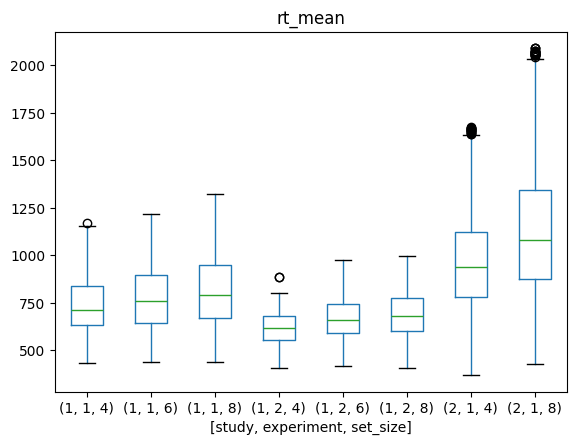

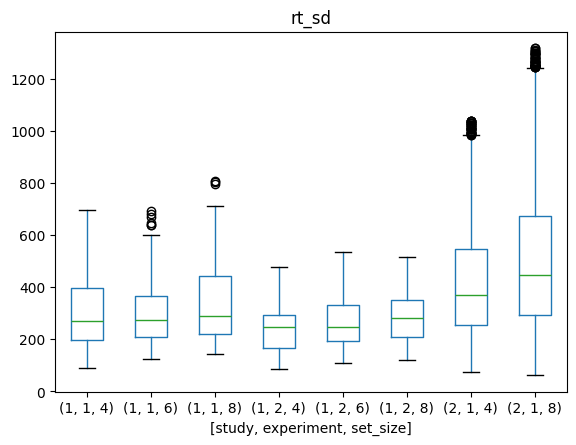

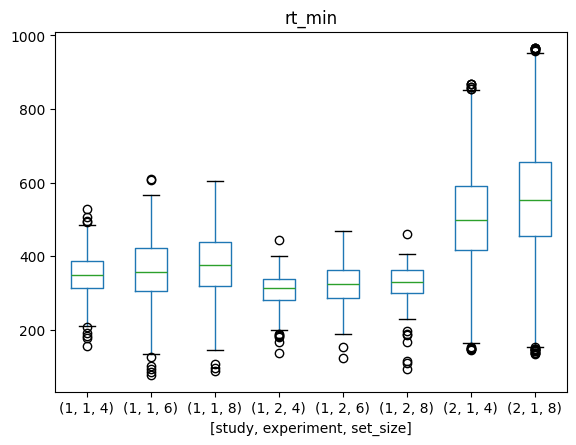

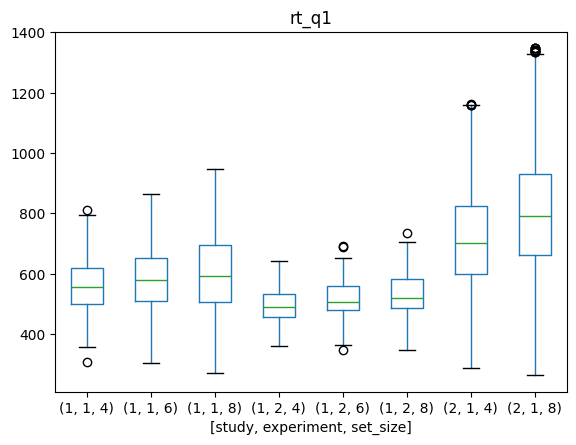

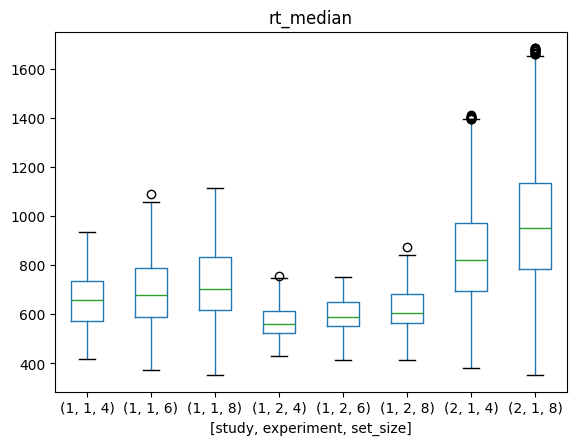

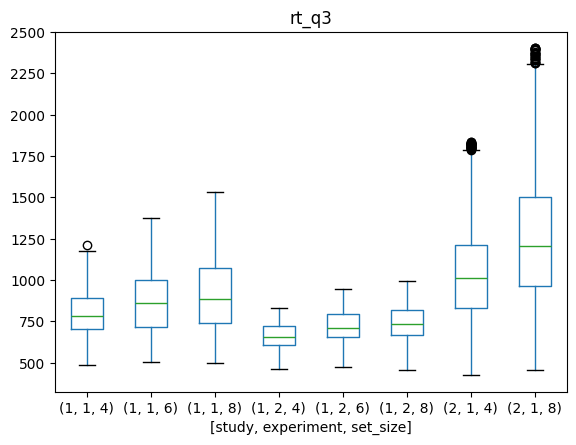

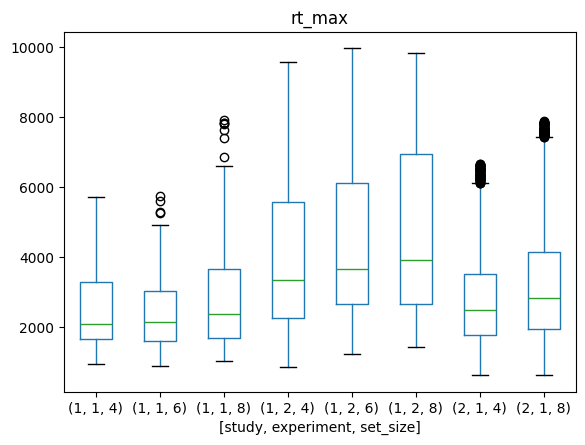

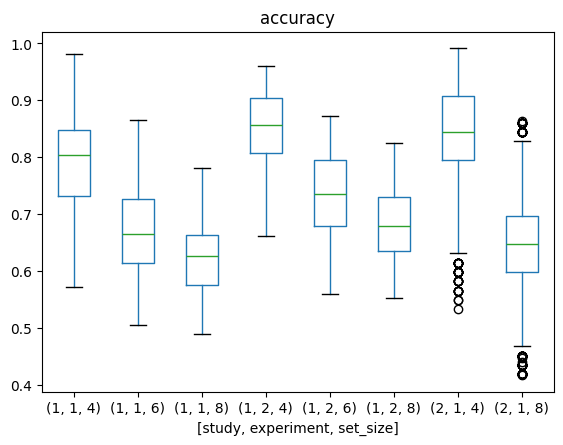

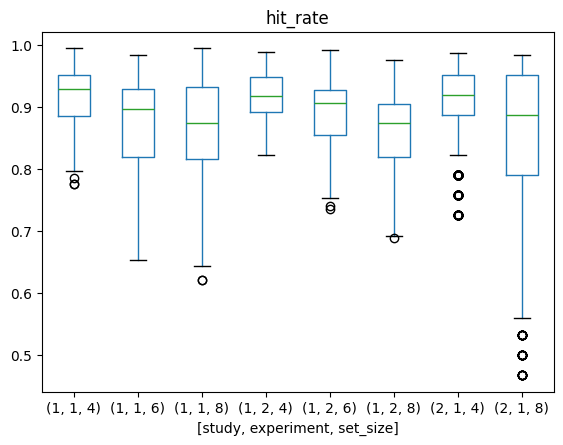

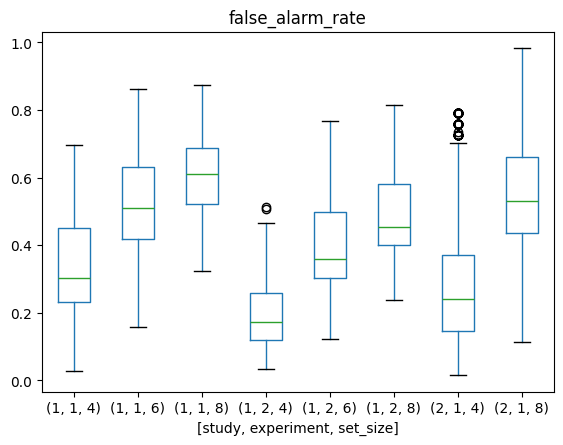

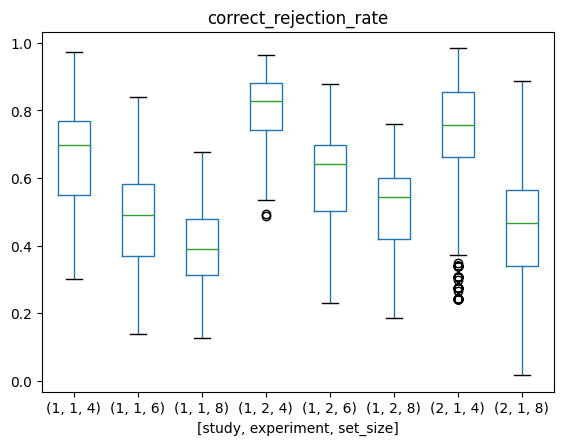

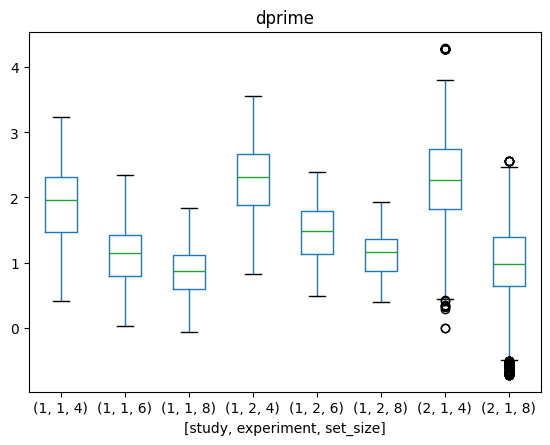

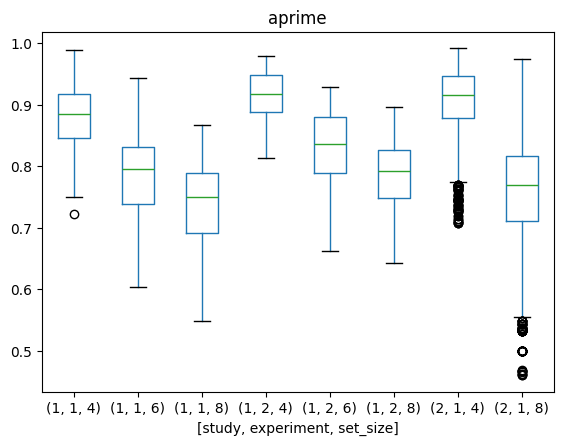

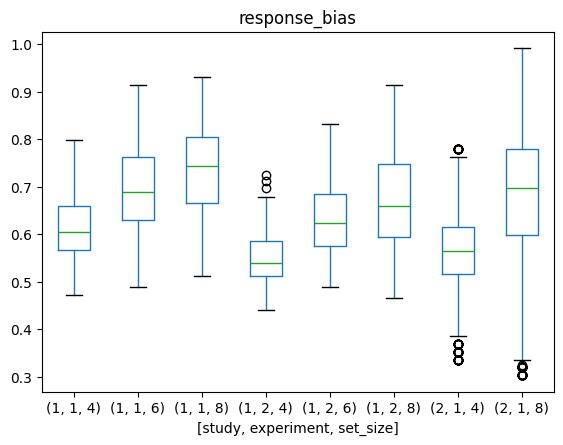

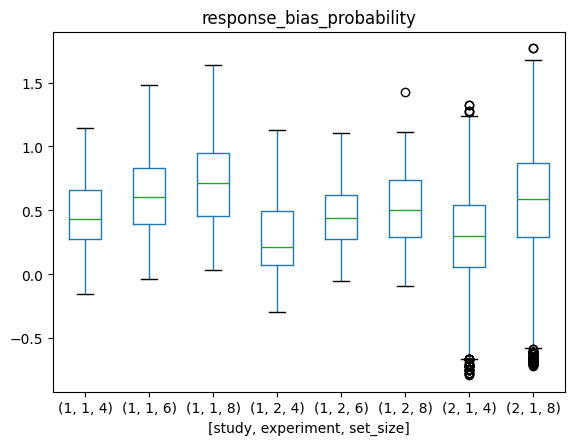

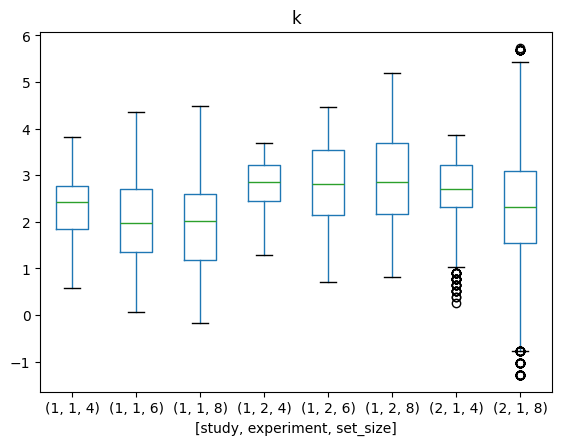

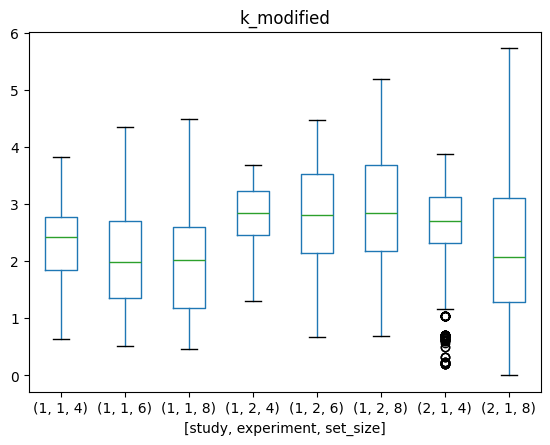

In [14]:
# Example Usage:

# 1. Grouped by multiple columns:
# plot_separate_boxplots(df=data, value_cols=variables_to_explore, group_cols=['study', 'experiment', 'set_size'])
#
# 2. Entire dataset (no grouping):
# plot_separate_histograms(df=data, value_cols=variables_to_explore, group_cols=None)     

plot_separate_boxplots(data, value_cols=variables_to_explore, group_cols=grouping_variables)

<H2>Plot histograms for each variable</H2>

In [15]:
def plot_separate_histograms(df, value_cols, group_cols=None, figsize=(10, 6), bins=30):
    """
    Returns a plot for each column in the value_col, 
    with histograms grouped by levels of each variable in the group_col,
    with independent axes for each plot.
    """
    
    if not group_cols:
        for i, column in enumerate(value_cols):  
            ax = df.hist(column=column, grid=False)
            plt.suptitle('')  
            plt.show()

    else:
        for i, column in enumerate(value_cols):  
            ax = df.hist(column=column, by=group_cols, grid=False)
            plt.suptitle(column)  
            plt.show()

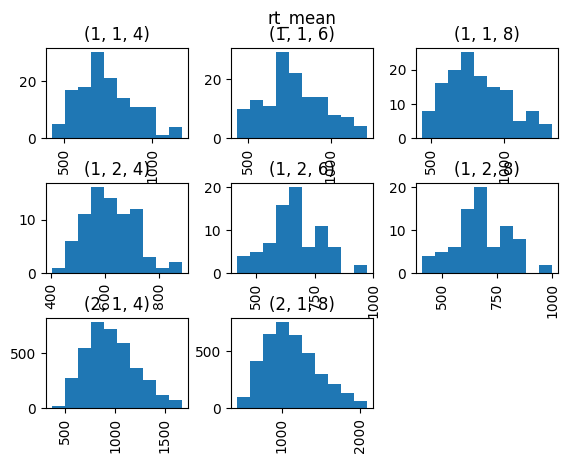

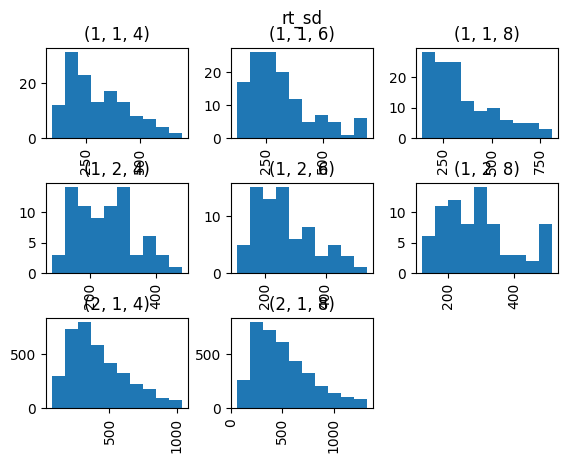

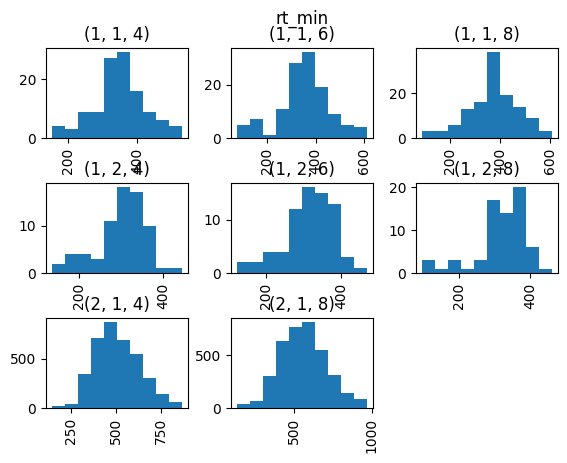

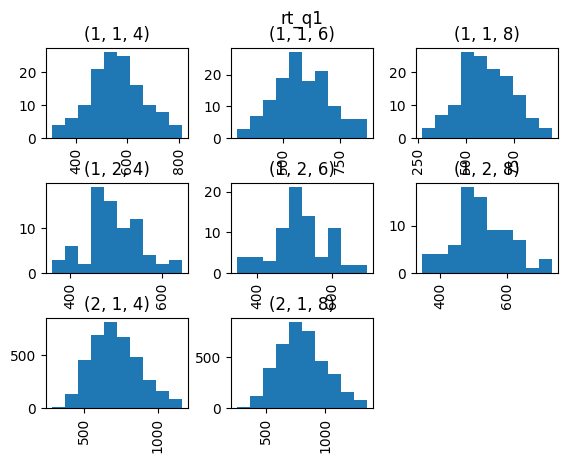

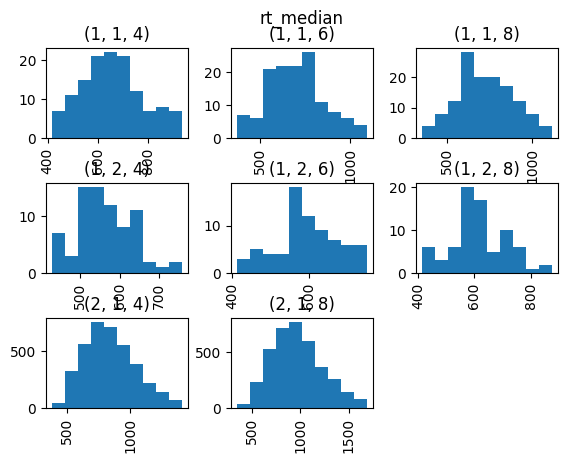

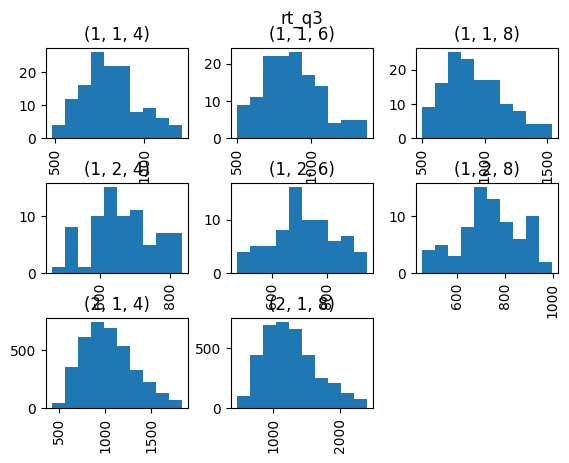

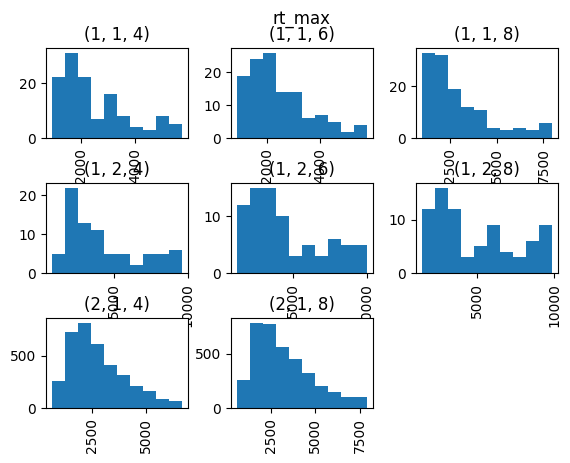

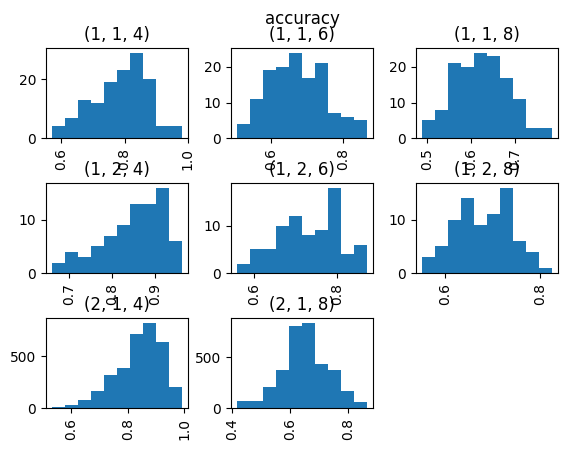

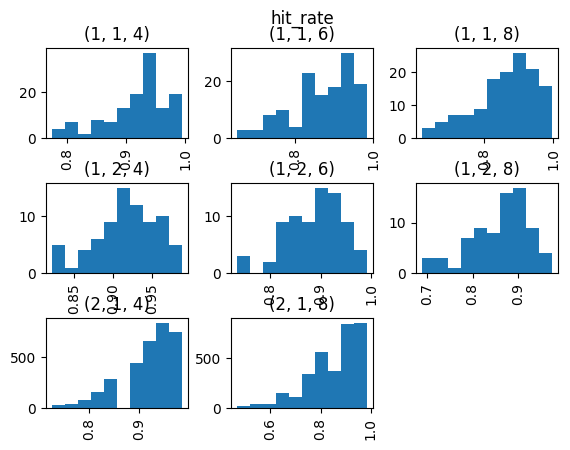

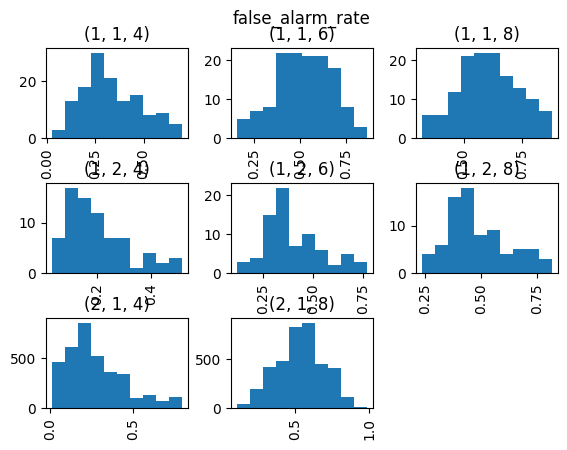

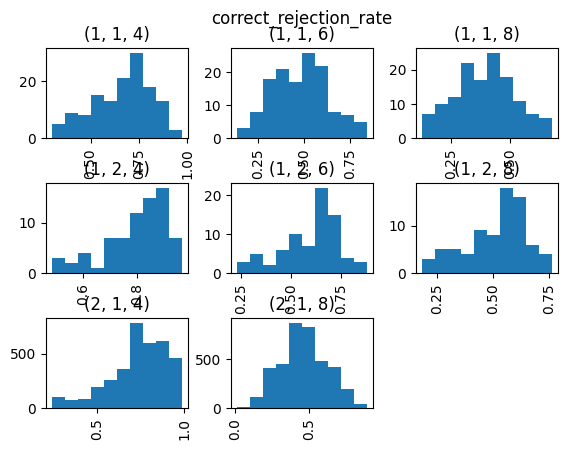

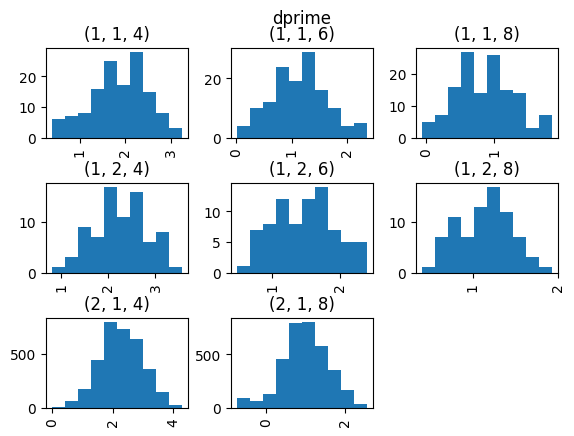

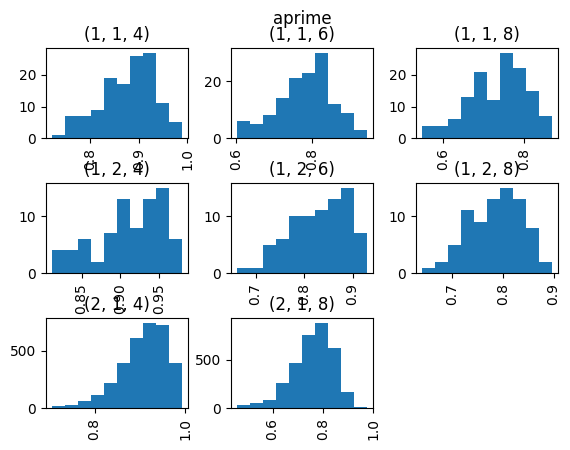

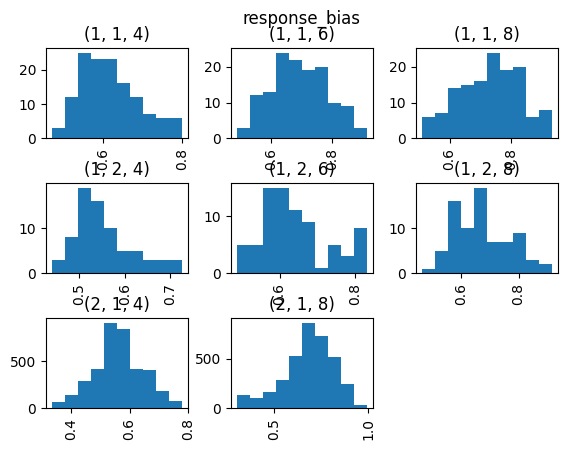

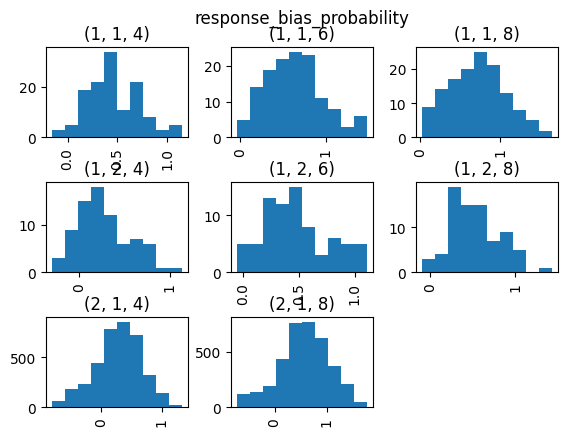

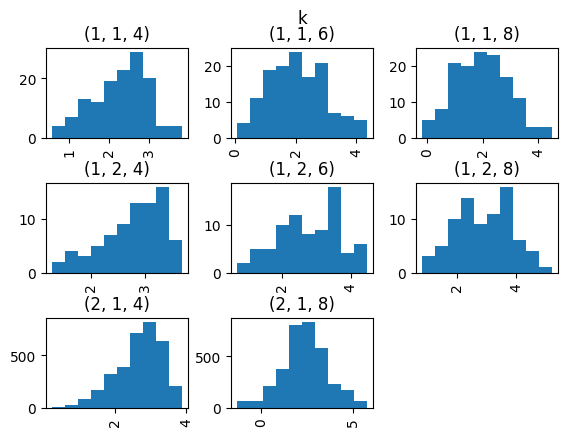

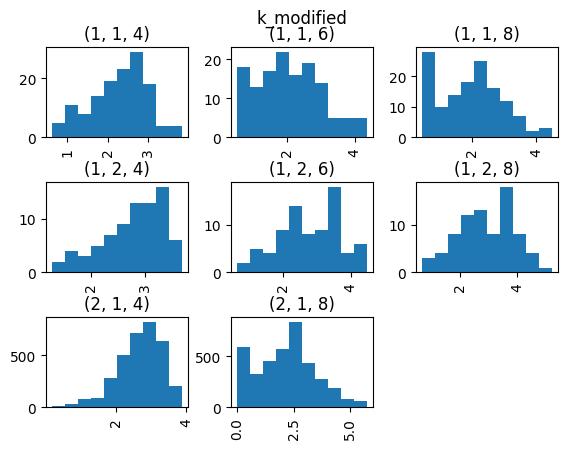

In [16]:
# Example Usage:

# 1. Grouped by multiple columns:
# plot_separate_histograms(df=data, value_cols=variables_to_explore, group_cols=['study', 'experiment', 'set_size'])
#
# 2. Entire dataset (no grouping):
# plot_separate_histograms(df=data, value_cols=variables_to_explore, group_cols=None)     

plot_separate_histograms(data, value_cols=variables_to_explore, group_cols=grouping_variables)

<H2>Plot correlation heatmaps</H2>

In [17]:
def correlation_heatmap(df, value_cols, group_cols=None, figsize=(15, 15)):
    """
    Plots a heatmap of a correlation matrix for each unique combination of grouping variables.
    If group_cols is None, it plots a single heatmap for the entire dataframe.
    
    Parameters:
    - df (pd.DataFrame): The input dataframe.
    - value_cols (list): List of column names to calculate correlations for.
    - group_cols (list or None): List of column names to group by, or None for the entire dataset.
    - figsize (tuple): Size of the figure.
    """
    # Filter dataframe to only include relevant columns and drop NaNs
    cols_to_use = (group_cols if group_cols else []) + value_cols
    df_subset = df.dropna(subset=cols_to_use).copy()
    
    if df_subset.empty:
        print("Error: No data remaining after dropping NaNs in specified columns.")
        return

    # Case 1: No grouping (group_cols is None or empty)
    if not group_cols:
        plt.figure(figsize=figsize)
        corr_matrix = df_subset[value_cols].corr()
        
        if corr_matrix.empty or corr_matrix.isnull().all().all():
            print("Error: Could not calculate correlation matrix (insufficient data or all NaNs).")
            plt.close()
            return
            
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
        plt.title("Correlation Matrix (Entire Dataset)")
        plt.tight_layout()
        plt.show()
        return

    # Case 2: Grouping by one or more columns
    group_combinations = df_subset[group_cols].drop_duplicates().sort_values(by=group_cols)
    n_groups = len(group_combinations)
    
    if n_groups == 0:
        print("Error: No unique group combinations found.")
        return

    # Calculate grid dimensions
    n_cols = int(np.ceil(np.sqrt(n_groups)))
    n_rows = int(np.ceil(n_groups / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0], figsize[1]))
    
    # Handle axis reshaping for edge cases
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
        
    axes = axes.flatten()
    valid_plot_count = 0
    
    for i, (_, group_vals) in enumerate(group_combinations.iterrows()):
        # Construct dynamic filter mask
        mask = pd.Series([True] * len(df_subset), index=df_subset.index)
        for col, val in zip(group_cols, group_vals):
            mask &= df_subset[col] == val
        
        group_data = df_subset.loc[mask, value_cols]
        
        if len(group_data) < 2:
            axes[i].axis('off')
            continue
            
        try:
            corr_matrix = group_data.corr()
            
            if corr_matrix.empty or corr_matrix.isnull().all().all():
                axes[i].axis('off')
                continue

            sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[i], cbar=False)
            title = ", ".join([f"{col}={val}" for col, val in zip(group_cols, group_vals)])
            axes[i].set_title(title, fontsize=10)
            valid_plot_count += 1
            
        except Exception as e:
            print(f"Skipping group {group_vals.to_dict()} due to error: {e}")
            axes[i].axis('off')

    # Hide unused subplots
    for j in range(valid_plot_count, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()      

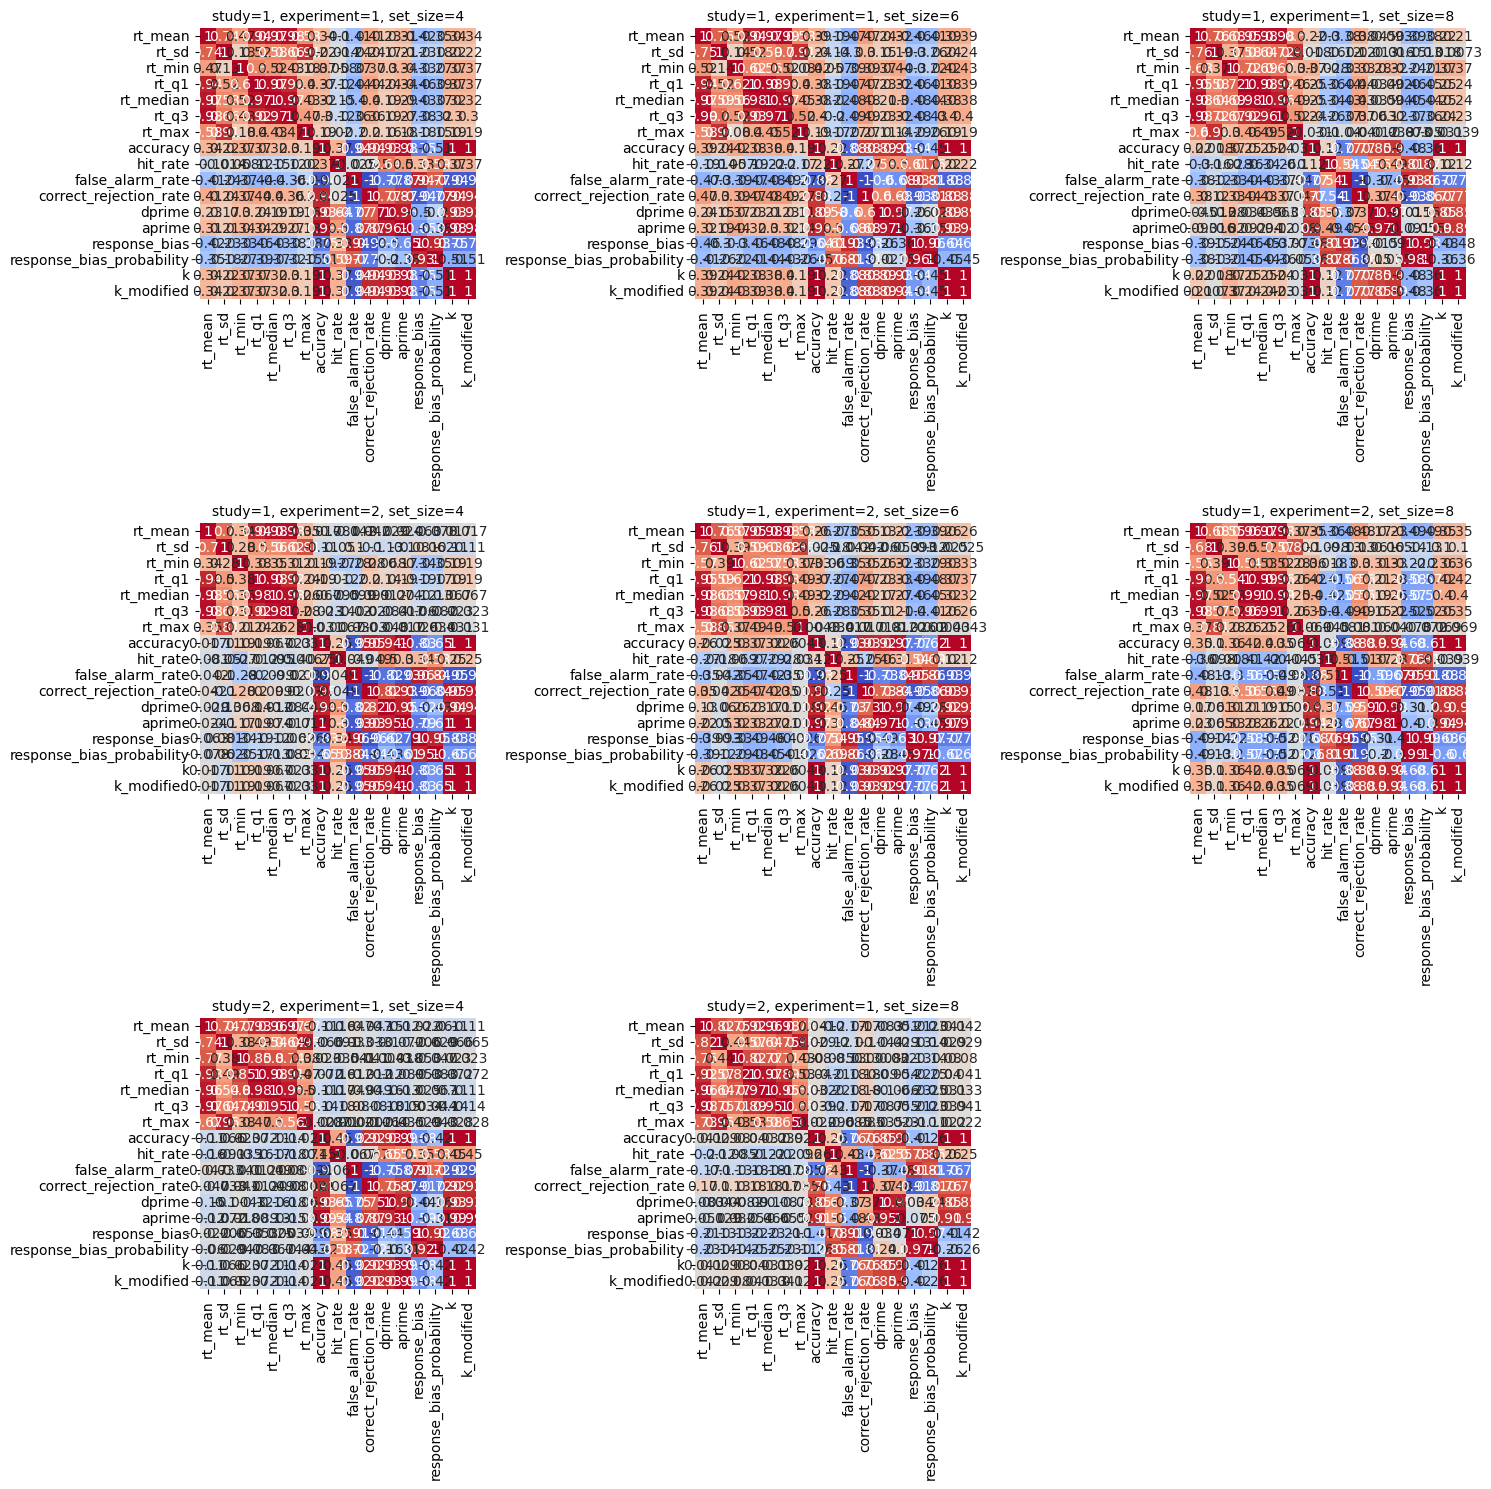

In [18]:
# Example Usage:

# 1. Grouped by multiple columns:
# correlation_heatmap(df, variables_to_explore, ['study', 'experiment', 'set_size'])
#
# 2. Entire dataset (no grouping):
# correlation_heatmap(df, variables_to_explore, None)     

correlation_heatmap(data, value_cols=variables_to_explore, group_cols=grouping_variables)

<H2>Scatterplots of pairs of variables fit with polynomial functions</H2>

In [19]:
def scatterplots_with_polynomial_fit(df, value_cols, group_cols=None, degree=1):
    """
    Plots scatter plots with polynomial fit curves for all unique column pairs,
    separated by unique combinations of multiple grouping columns.
    
    Parameters:
    - df: pandas DataFrame containing numeric data and grouping columns.
    - value_cols (list): List of column names to calculate correlations for.
    - group_cols (list or None): column names to group by (e.g., ['study', 'experiment, 'set_size]).
    - degree: int, degree of the polynomial fit (default=1 for linear).
    """
    # Ensure group_cols is a list
    if isinstance(group_cols, str):
        group_cols = [group_cols]
        
    # Identify numeric columns excluding grouping columns
    value_cols = df[value_cols].columns.tolist()
        
    if len(value_cols) < 2:
        print("Not enough numeric columns to plot pairs.")
        return

    # Get unique group combinations
    # groupby returns an iterator of (group_key, group_dataframe)
    # group_key is a tuple if multiple group_cols are provided
    grouped = df.groupby(group_cols)
    n_groups = len(grouped)
    
    # Calculate unique pairs of numeric columns
    col_pairs = list(combinations(value_cols, 2))
    n_pairs = len(col_pairs)
    
    if n_groups == 0 or n_pairs == 0:
        print("No groups or column pairs to plot.")
        return

    # Total subplots = groups * pairs
    total_plots = n_groups * n_pairs
    
    # Determine grid shape
    n_cols_grid = 3
    n_rows_grid = int(np.ceil(total_plots / 3))
    
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5 * n_cols_grid, 5 * n_rows_grid))
    
    # Flatten axes for easy iteration
    if n_rows_grid > 1:
        axes = axes.flatten()
    else:
        axes = [axes] if total_plots > 1 else [axes]

    plot_idx = 0
    
    # Iterate through each group combination
    for group_key, group_df in grouped:
        # Format group title (handle single vs multiple group columns)
        if len(group_cols) == 1:
            group_label = str(group_key)
        else:
            group_label = ", ".join(str(k) for k in group_key)
            
        # Iterate through each unique column pair
        for col1, col2 in col_pairs:
            if plot_idx >= len(axes):
                break
                
            ax = axes[plot_idx]
            
            # Data cleaning
            x = group_df[col1].dropna()
            y = group_df[col2].dropna()
            common_index = x.index.intersection(y.index)
            x = x.loc[common_index]
            y = y.loc[common_index]
            
            if len(x) < degree + 1:
                ax.text(0.5, 0.5, "Insufficient Data", transform=ax.transAxes, ha='center', va='center')
                ax.set_title(f"{group_label}\n{col1} vs {col2}")
                ax.set_xlabel(col1)
                ax.set_ylabel(col2)
                plot_idx += 1
                continue
            
            # Scatter plot
            ax.scatter(x, y, alpha=0.5, s=20, label='Data')
            
            # Polyfit
            coeffs = np.polyfit(x, y, degree)
            poly_fn = np.poly1d(coeffs)
            
            # Plot fit line
            x_sorted = np.sort(x)
            ax.plot(x_sorted, poly_fn(x_sorted), color='red', linewidth=2, label=f'Fit (deg {degree})')
            
            # Correlation coefficient
            corr = np.corrcoef(x, y)[0, 1]
            
            ax.set_xlabel(col1)
            ax.set_ylabel(col2)
            ax.set_title(f"{group_label}\n{col1} vs {col2} (Corr: {corr:.2f})")
            ax.legend(fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.3)
            
            plot_idx += 1

    # Hide unused subplots
    for i in range(plot_idx, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


In [20]:
# Example Usage:

# 1. Grouped by multiple columns:
# scatterplots_with_polynomial_fit(df=data, value_cols=variables_to_explore, group_cols=['study', 'experiment', 'set_size'])
#
# 2. Entire dataset (no grouping):
# scatterplots_with_polynomial_fit(df=data, value_cols=variables_to_explore, group_cols=None)     

#Uncomment to run-this creates a very big file
#scatterplots_with_polynomial_fit(data, value_cols=variables_to_explore, group_cols=grouping_variables, degree=5)